### 학습목표
- 순환신경망 개념을 이해 할 수 있다.
- 바닐라RNN의 단점을 이해하고 개선된 LSTM을 이해 할 수 있다.
- 자연어처리 성능을 높이기 위한 임베딩 기법을 이해 할 수 있다

In [14]:
# 작업디렉토리 변경
%cd "/content/drive/MyDrive/AI/26.06.10 자연어처리"

from google.colab import drive
drive.mount('/content/drive')

/content/drive/MyDrive/AI/26.06.10 자연어처리
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### RNNN의 특징
- 이전데이터가 다음데이터에 영향을 주는 Sequential한 데이터를 학습시키기 위해등장 (ex:문장,음악,주식,날씨 등)
- 입력데이터를 시간순에 따라서 쪼개고 순차적으로 집어 넣는 방식을 채택
- 현재 입력데이터와 직전(과거)메모리를 합산하는 수식으로 계산

### RNN의 특징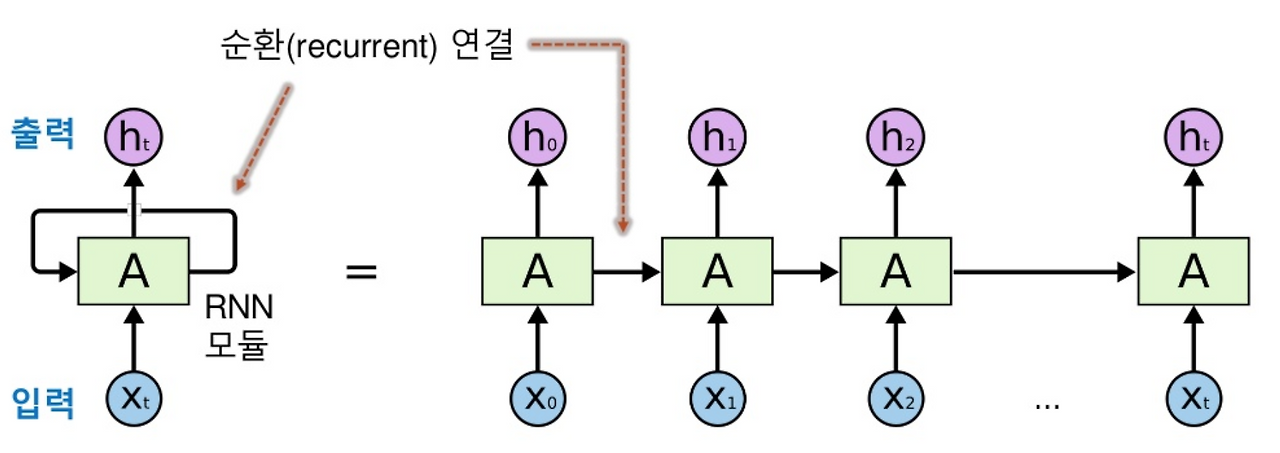

### 네이버영화 리뷰데이터 감성분석
- 네이버영화 리뷰를 수집(평점도 함께 수집)
- 리뷰데이터가 긍정/부정인지 판별하는 데이터 셋
- https://github.com/e9t/nsmc

#### 감성분석
- 텍스트가 가지고 있는 의도나 감정을 파악하는 분석기법
- 전통적인 감성분석
  - 감성사전을 기반으로 해당단어의 빈도를 측정
- 현재 감성분석
  - 신경망 기반의 학습/추론

In [2]:
#데이터로딩
import pandas as pd

In [30]:
train_df = pd.read_csv('/content/drive/My Drive/AI/data/ratings_train.txt', delimiter='\t')
test_df = pd.read_csv('/content/drive/My Drive/AI/data/ratings_test.txt', delimiter='\t')

In [10]:
# Comprehensive Mecab installation script for Google Colab
# This script installs the Mecab C++ library, its Korean dictionary, and the mecab-python3 binding.
# It addresses common issues with outdated download links and ensures proper setup.

# 1. Update apt-get and install necessary build tools and Java
!apt-get update -qq
!apt-get install -y g++ openjdk-8-jdk python3-dev python3-pip curl > /dev/null

# 2. Install Mecab-ko and Mecab-ko-dic using konlpy's official script
# This script handles the downloading, compiling, and installation of Mecab and its Korean dictionary.
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) > /dev/null

# 3. Install the mecab-python3 binding
!pip install mecab-python3 > /dev/null

print("Mecab and mecab-python3 installation complete. Please RESTART YOUR RUNTIME for changes to take effect.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
<string>:1: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
Mecab and mecab-python3 installation complete. Please RESTART YOUR RUNTIME for changes to take effect.


In [4]:
print(train_df.shape, test_df.shape)
display(train_df.head())

(150000, 3) (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [5]:
train_df.shape, test_df.shape

((150000, 3), (50000, 3))

In [18]:
train_df.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


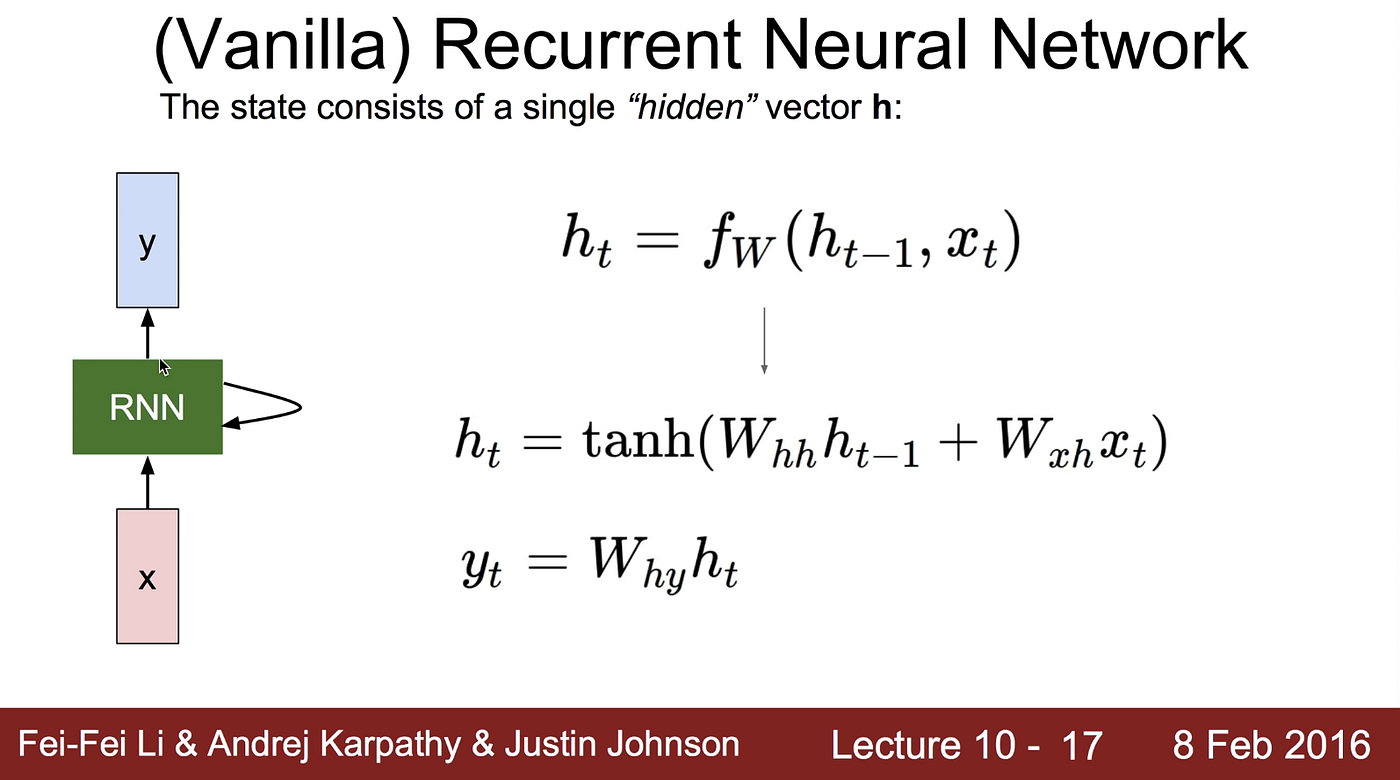

#### 학습을 위한 전처리
- 숫자, 영어, 문장부호
- 형태소분석기 활용 토큰화

In [19]:
import re

In [20]:
sample_text = "a123안녕하세요. 111반갑습니다."
rs = re.sub('[a-z0-9]+', '',sample_text)
rs

'안녕하세요. 반갑습니다.'

In [33]:
from mecab import MeCab
mecab = MeCab()

ModuleNotFoundError: No module named 'mecab'

In [ ]:
!pip install mecab-python3

In [34]:
for doc in train_df['document'].head(5) :
  rs = re.sub('[a-zA-Z0-9.?!]+','',doc) # 정규표현식 전처리
  morphs = mecab.morphs(rs) # 형태소단위로 분리
  print(' '.join(morphs))

NameError: name 'mecab' is not defined

In [35]:
prepro essed_train

SyntaxError: invalid syntax (580336528.py, line 1)

In [36]:
from konlpy.tag import Mecab

In [37]:
#반복처리 진행상황을 시각화하는 도구
from tqdm import tqdm

In [38]:
preprocessed_train = [] # 전처리된 결과물을 담을 리스트


In [39]:
#테스트데이터 적용하기
preprocessed_test = [] # 전처리된 결과물을 담을 리스트
for doc in tqdm(test_df['document']) :
  rs = re.sub('[a-zA-Z0-9.?!]+', '', str(doc)) # 정규표현식 전처리
  morphs = mecab.morphs(rs) # 형태소단위로 분리
  preprocessed_test.append(' '.join(morphs))

  0%|          | 0/50000 [00:00<?, ?it/s]


NameError: name 'mecab' is not defined

#### 토큰화 및 수치화
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization

In [41]:
# 텍스트데이터를 토큰화/수치화 해주는 도구
from tensorflow.keras.layers import TextVectorization

In [44]:
vectorizer = TextVectorization(
    max_tokens = 5000, # 빈도가 높은 상위 5000개 단어만 사전으로 등록
    output_mode = 'int', # 단어사전에 등록된 수번 번호로 수치화
    standardize = "lower_and_strip_punctuation" , # 소문자변환 및 불필요 문장
    output_sequence_length = 10 # 시퀀스 길이 통일
)